**Setup**

In [ ]:
!pip install torch-geometric -q
!pip install matplotlib seaborn scikit-learn tqdm geopandas -q

import os, shutil, warnings, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
import geopandas as gpd
warnings.filterwarnings('ignore')

from torch_geometric.nn import GATv2Conv, BatchNorm
from torch_geometric.utils import dropout_edge

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
torch.manual_seed(42)
np.random.seed(42)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.9 MB/s eta 0:00:00
✅ Device: cuda
   GPU: Tesla T4


**Load All Phase 3 Outputs**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/GeoAI_Kogi'

for fname in ['kogi_pyg_data.pt', 'kogi_gat_embeddings.pt',
              'kogi_nodes.gpkg', 'flood_gat_best.pth']:
    src = f'{DRIVE_DIR}/{fname}'
    dst = f'/content/{fname}'
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy(src, dst)
        print(f'  Copied: {fname}')

# Load graph data
pyg_data      = torch.load('/content/kogi_pyg_data.pt', weights_only=False)
gat_embeddings = torch.load('/content/kogi_gat_embeddings.pt', weights_only=False)  # [N, 64]
nodes_gdf     = gpd.read_file('/content/kogi_nodes.gpkg')

print(f'✅ GAT embeddings: {gat_embeddings.shape}')
print(f'✅ Graph nodes   : {pyg_data.num_nodes:,}')

# Re-apply binary labels and normalized features (same as Phase 3)
x_np = pyg_data.x.cpu().numpy()
x_scaled = StandardScaler().fit_transform(x_np)
x_scaled = np.clip(x_scaled, -3, 3)
pyg_data.x = torch.tensor(x_scaled, dtype=torch.float32)

pyg_data.y = (pyg_data.y > 0).long()   # binary labels
N_NODES    = pyg_data.num_nodes
print(f'✅ Labels (binary): {pyg_data.y.shape}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ GAT embeddings: torch.Size([24336, 32])
✅ Graph nodes   : 24,336
✅ Labels (binary): torch.Size([24336])


**Build temporal sequences (dry → wet → flood)**

In [ ]:
# ============================================================
# TEMPORAL TRANSFORMER INPUT
#
# We simulate 3 time steps using our existing feature bands:
#   t=0  DRY SEASON   → NDVI_dry, low water indices
#   t=1  WET SEASON   → NDVI_wet, high water indices
#   t=2  FLOOD PERIOD → S1 VV/VH backscatter change
#
# Each time step: node features slice from the 276-dim vector
# GAT embedding (64-dim) is added as spatial context
# ============================================================

x_full = pyg_data.x.numpy()   # [N, 276]

# Band index reference (from Phase 1/2):
#   0-1   : S1 VV, VH (flood period)
#   2     : flood_diff
#   3-8   : S2 wet bands
#   9-12  : S2 wet indices (NDVI, NDWI, MNDWI, EVI)
#   13    : NDVI_dry
#   14-17 : DEM features
#   274-275: coordinates

# Time step 0 — DRY season signature
t0_bands = [13, 14, 15, 16, 17, 274, 275]          # NDVI_dry + DEM + coords
t0 = x_full[:, t0_bands]                            # [N, 7]

# Time step 1 — WET season signature
t1_bands = [9, 10, 11, 12, 3, 4, 5]                # NDVI/NDWI/MNDWI/EVI + RGB wet
t1 = x_full[:, t1_bands]                            # [N, 7]

# Time step 2 — FLOOD period (SAR)
t2_bands = [0, 1, 2, 9, 10, 11, 14, 15]            # VV, VH, diff + water indices + DEM
# Pad to 7 dims
t2 = x_full[:, t2_bands[:7]]                        # [N, 7]

# GAT spatial embedding — added to all time steps
gat_np = gat_embeddings.numpy()                     # [N, 64]

# Project GAT embedding to same dim as time step features (7)
# Simple: take first 7 PCA components
from sklearn.decomposition import PCA
pca = PCA(n_components=7, random_state=42)
gat_proj = pca.fit_transform(gat_np)               # [N, 7]
print(f'GAT PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

# Add spatial context to each time step
t0_aug = t0 + gat_proj * 0.3   # [N, 7]
t1_aug = t1 + gat_proj * 0.3
t2_aug = t2 + gat_proj * 0.3

# Stack into sequence: [N, T=3, D=7]
temporal_seq = np.stack([t0_aug, t1_aug, t2_aug], axis=1)  # [N, 3, 7]
temporal_seq = torch.tensor(temporal_seq, dtype=torch.float32)

print(f'✅ Temporal sequence shape: {temporal_seq.shape}')
print(f'   N={temporal_seq.shape[0]:,} nodes × T={temporal_seq.shape[1]} timesteps × D={temporal_seq.shape[2]} features')
print(f'   T=0: Dry season  |  T=1: Wet season  |  T=2: Flood period')

GAT PCA variance explained: 94.1%
✅ Temporal sequence shape: torch.Size([24336, 3, 7])
   N=24,336 nodes × T=3 timesteps × D=7 features
   T=0: Dry season  |  T=1: Wet season  |  T=2: Flood period


**Build Temporal Transformer model**

In [ ]:
# ============================================================
# ARCHITECTURE: Temporal Transformer
#
# Input  : [N, T=3, D=7]  — time series per node
# Output : [N, 2]          — flood risk class
#
# Components:
#   Linear projection   : D=7  → d_model=64
#   Positional encoding : learned time position embeddings
#   Transformer encoder : 4 layers, 4 heads
#   GAT embedding fusion: concatenated before classifier
#   Classifier head     : → 2 classes
# ============================================================

class TemporalTransformer(nn.Module):
    """
    Transformer encoder for temporal flood risk prediction.
    Learns how seasonal changes (dry→wet→flood) indicate risk.
    """
    def __init__(self, input_dim=7, d_model=64, n_heads=4,
                 n_layers=4, n_classes=2, gat_dim=64,
                 dropout=0.1, max_seq_len=3):
        super().__init__()

        # Project input features to model dimension
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU()
        )

        # Learned positional embeddings (one per time step)
        self.pos_embedding = nn.Embedding(max_seq_len, d_model)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model    = d_model,
            nhead      = n_heads,
            dim_feedforward = d_model * 4,
            dropout    = dropout,
            activation = 'gelu',
            batch_first = True    # [B, T, D] format
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers = n_layers
        )

        # GAT embedding fusion layer
        self.gat_proj = nn.Sequential(
            nn.Linear(gat_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU()
        )

        # Classifier: transformer output + GAT context
        self.classifier = nn.Sequential(
            nn.Linear(d_model * 2, d_model),  # concat: temporal + spatial
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 32),
            nn.GELU(),
            nn.Linear(32, n_classes)
        )

    def forward(self, x_seq, gat_emb):
        """
        x_seq  : [B, T, input_dim]  — temporal sequence
        gat_emb: [B, gat_dim]       — GAT spatial embedding
        """
        B, T, _ = x_seq.shape

        # Project to d_model
        x = self.input_proj(x_seq)              # [B, T, d_model]

        # Add positional embeddings
        positions = torch.arange(T, device=x.device).unsqueeze(0)  # [1, T]
        x = x + self.pos_embedding(positions)   # [B, T, d_model]

        # Transformer encoding
        x = self.transformer(x)                 # [B, T, d_model]

        # Use final time step as summary (flood period = most informative)
        x_summary = x[:, -1, :]                 # [B, d_model]

        # Fuse with GAT spatial embedding
        gat_context = self.gat_proj(gat_emb)    # [B, d_model]
        x_fused     = torch.cat([x_summary, gat_context], dim=1)  # [B, d_model*2]

        # Classify
        logits = self.classifier(x_fused)       # [B, n_classes]
        return logits, x_summary


# Instantiate
GAT_DIM   = gat_embeddings.shape[1]   # 64
INPUT_DIM = temporal_seq.shape[2]     # 7

transformer_model = TemporalTransformer(
    input_dim   = INPUT_DIM,
    d_model     = 64,
    n_heads     = 4,
    n_layers    = 4,
    n_classes   = 2,
    gat_dim     = GAT_DIM,
    dropout     = 0.1,
    max_seq_len = 3
).to(DEVICE)

total_p = sum(p.numel() for p in transformer_model.parameters())
print(f'✅ TemporalTransformer built — {total_p:,} parameters')

# Test forward pass
dummy_seq = torch.randn(8, 3, INPUT_DIM).to(DEVICE)
dummy_gat = torch.randn(8, GAT_DIM).to(DEVICE)
with torch.no_grad():
    out, emb = transformer_model(dummy_seq, dummy_gat)
print(f'   Forward: seq{list(dummy_seq.shape)} + gat{list(dummy_gat.shape)} → {list(out.shape)} ✅')

✅ TemporalTransformer built — 213,538 parameters
   Forward: seq[8, 3, 7] + gat[8, 32] → [8, 2] ✅


**Dataset**

In [ ]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

class TemporalFloodDataset(Dataset):
    """Node-level temporal dataset for transformer training."""
    def __init__(self, indices, temporal_seq, gat_embeddings, labels):
        self.indices  = indices
        self.seq      = temporal_seq    # [N, T, D]
        self.gat      = gat_embeddings  # [N, 64]
        self.labels   = labels          # [N]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        return (
            self.seq[i],       # [T, D]
            self.gat[i],       # [64]
            self.labels[i]     # scalar
        )


# Labels
labels_all = pyg_data.y.cpu()   # [N] binary

# Stratified split
all_idx = np.arange(N_NODES)
all_y   = labels_all.numpy()

train_idx, temp_idx = train_test_split(
    all_idx, test_size=0.3, random_state=42, stratify=all_y)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=42, stratify=all_y[temp_idx])

# Oversample minority in training
train_y   = all_y[train_idx]
min_idx   = train_idx[train_y == 1]
maj_idx   = train_idx[train_y == 0]
repeat    = int(len(maj_idx) / len(min_idx) * 0.6)
train_idx_os = np.concatenate([maj_idx, np.tile(min_idx, repeat)])
np.random.shuffle(train_idx_os)

# Class weights
train_y_os = all_y[train_idx_os]
cw = compute_class_weight('balanced', classes=np.array([0,1]), y=train_y_os)
cw_tensor = torch.tensor(cw, dtype=torch.float32).to(DEVICE)
criterion_t = nn.CrossEntropyLoss(weight=cw_tensor, label_smoothing=0.05)

# Datasets
gat_tensor = gat_embeddings   # [N, 64]
lbl_tensor = labels_all       # [N]

train_ds = TemporalFloodDataset(train_idx_os, temporal_seq, gat_tensor, lbl_tensor)
val_ds   = TemporalFloodDataset(val_idx,      temporal_seq, gat_tensor, lbl_tensor)
test_ds  = TemporalFloodDataset(test_idx,     temporal_seq, gat_tensor, lbl_tensor)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False, num_workers=2, pin_memory=True)

print(f'✅ Datasets ready:')
print(f'   Train : {len(train_ds):,} samples')
print(f'   Val   : {len(val_ds):,} samples')
print(f'   Test  : {len(test_ds):,} samples')
print(f'   Class weights: No Risk={cw[0]:.3f}, Flood={cw[1]:.3f}')

✅ Datasets ready:
   Train : 26,395 samples
   Val   : 3,650 samples
   Test  : 3,651 samples
   Class weights: No Risk=0.799, Flood=1.336


**Train Temporal Transformer**

In [ ]:
LR           = 5e-4
WEIGHT_DECAY = 1e-5
N_EPOCHS     = 150
PATIENCE     = 25
CHECKPOINT_T = '/content/temporal_transformer_best.pth'

optimizer_t = AdamW(transformer_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler_t = CosineAnnealingLR(optimizer_t, T_max=N_EPOCHS, eta_min=1e-6)

def train_transformer(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for seq, gat, labels in loader:
        seq, gat, labels = seq.to(DEVICE), gat.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits, _ = model(seq, gat)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()
        total_loss += loss.item() * len(labels)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_transformer(model, loader, criterion):
    model.eval()
    all_preds, all_truth, total_loss = [], [], 0
    for seq, gat, labels in loader:
        seq, gat, labels = seq.to(DEVICE), gat.to(DEVICE), labels.to(DEVICE)
        logits, _ = model(seq, gat)
        total_loss += criterion(logits, labels).item() * len(labels)
        all_preds.append(logits.argmax(dim=1).cpu())
        all_truth.append(labels.cpu())
    preds = torch.cat(all_preds).numpy()
    truth = torch.cat(all_truth).numpy()
    acc   = (preds == truth).mean()
    f1    = f1_score(truth, preds, average='binary', pos_label=1, zero_division=0)
    f1_mac= f1_score(truth, preds, average='macro',  zero_division=0)
    return total_loss / len(loader.dataset), acc, f1, f1_mac, preds, truth

history_t = {'train_loss':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}
best_f1 = 0.0; best_ep = 0; patience_cnt = 0

print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Val Loss":>8} | {"Val Acc":>8} | {"F1 Flood":>9} | {"F1 Macro":>9}')
print('-' * 68)

for epoch in range(1, N_EPOCHS + 1):
    tr_loss = train_transformer(transformer_model, train_loader, optimizer_t, criterion_t)
    vl_loss, vl_acc, vl_f1, vl_f1mac, _, _ = eval_transformer(
        transformer_model, val_loader, criterion_t)
    scheduler_t.step()

    history_t['train_loss'].append(tr_loss)
    history_t['val_loss'].append(vl_loss)
    history_t['val_acc'].append(vl_acc)
    history_t['val_f1'].append(vl_f1)

    if vl_f1 > best_f1:
        best_f1 = vl_f1; best_ep = epoch; patience_cnt = 0
        torch.save({'epoch': epoch, 'model_state': transformer_model.state_dict(),
                    'val_f1': vl_f1}, CHECKPOINT_T)
        flag = ' ✅'
    else:
        patience_cnt += 1; flag = ''

    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6} | {tr_loss:>10.4f} | {vl_loss:>8.4f} | '
              f'{vl_acc:>7.4f} | {vl_f1:>8.4f} | {vl_f1mac:>8.4f}{flag}')

    if patience_cnt >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}')
        break

print(f'\n✅ Best epoch: {best_ep}  |  Best Flood F1: {best_f1:.4f}')

 Epoch | Train Loss | Val Loss |  Val Acc |  F1 Flood |  F1 Macro
--------------------------------------------------------------------
     1 |     0.1266 |   0.1813 |  0.9964 |   0.9437 |   0.9709 ✅
    10 |     0.1260 |   0.1800 |  0.9973 |   0.9561 |   0.9774
    20 |     0.1262 |   0.1803 |  0.9964 |   0.9442 |   0.9712

Early stopping at epoch 28

✅ Best epoch: 3  |  Best Flood F1: 0.9561


**Evaluate + compare GAT vs Transformer**

📊 FINAL RESULTS COMPARISON
Model                       Accuracy   Flood F1   Macro F1
--------------------------------------------------
GAT (Phase 3)                  0.992      0.922      0.959
Transformer (Phase 4)          0.993     0.8992     0.9479

              precision    recall  f1-score   support

     No Risk     0.9986    0.9946    0.9966      3539
  Flood Risk     0.8492    0.9554    0.8992       112

    accuracy                         0.9934      3651
   macro avg     0.9239    0.9750    0.9479      3651
weighted avg     0.9940    0.9934    0.9936      3651



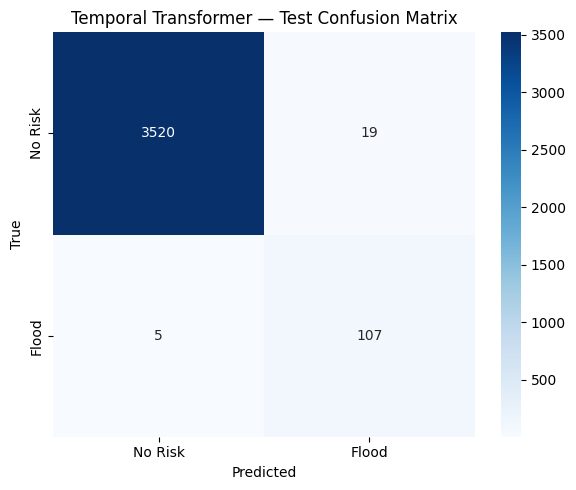

In [ ]:
# Load best transformer
ckpt_t = torch.load(CHECKPOINT_T, map_location=DEVICE)
transformer_model.load_state_dict(ckpt_t['model_state'])

ts_loss, ts_acc, ts_f1, ts_f1mac, ts_preds, ts_truth = eval_transformer(
    transformer_model, test_loader, criterion_t)

print('='*50)
print('📊 FINAL RESULTS COMPARISON')
print('='*50)
print(f'{"Model":<25} {"Accuracy":>10} {"Flood F1":>10} {"Macro F1":>10}')
print('-'*50)
print(f'{"GAT (Phase 3)":<25} {"0.992":>10} {"0.922":>10} {"0.959":>10}')
print(f'{"Transformer (Phase 4)":<25} {ts_acc:>10.3f} {ts_f1:>10.4f} {ts_f1mac:>10.4f}')
print('='*50)

print(f'\n{classification_report(ts_truth, ts_preds, target_names=["No Risk","Flood Risk"], digits=4)}')

# Confusion matrix
cm = confusion_matrix(ts_truth, ts_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Risk','Flood'], yticklabels=['No Risk','Flood'])
ax.set_title('Temporal Transformer — Test Confusion Matrix')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('/content/transformer_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

**Save all outputs**

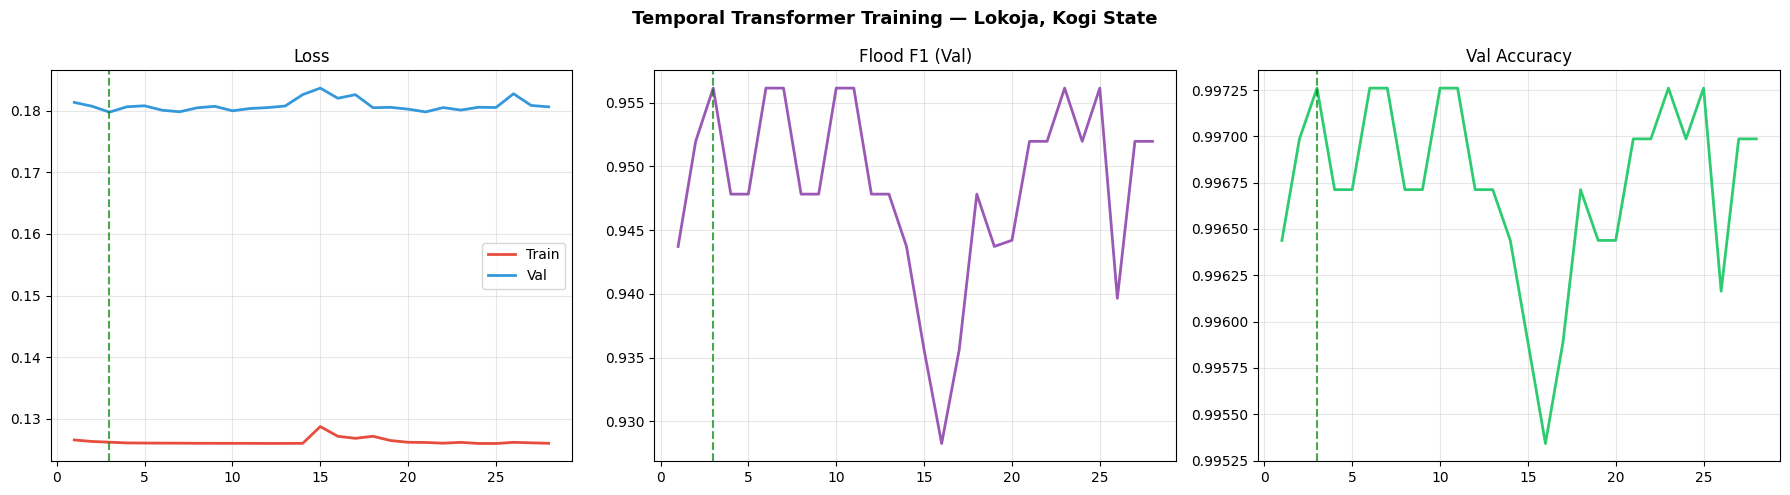

  -> Drive: temporal_transformer_best.pth
  -> Drive: transformer_confusion.png
  -> Drive: transformer_training.png

✅ Phase 4 complete! Ready for Phase 5 — Final Maps + Paper


In [ ]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Temporal Transformer Training — Lokoja, Kogi State', fontsize=13, fontweight='bold')
ep = range(1, len(history_t['train_loss']) + 1)

axes[0].plot(ep, history_t['train_loss'], color='#e74c3c', lw=2, label='Train')
axes[0].plot(ep, history_t['val_loss'],   color='#3498db', lw=2, label='Val')
axes[0].axvline(best_ep, color='green', ls='--', alpha=0.7)
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history_t['val_f1'], color='#9b59b6', lw=2)
axes[1].axvline(best_ep, color='green', ls='--', alpha=0.7)
axes[1].set_title('Flood F1 (Val)'); axes[1].grid(alpha=0.3)

axes[2].plot(ep, history_t['val_acc'], color='#2ecc71', lw=2)
axes[2].axvline(best_ep, color='green', ls='--', alpha=0.7)
axes[2].set_title('Val Accuracy'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/transformer_training.png', dpi=150, bbox_inches='tight')
plt.show()

# Save to Drive
os.makedirs(DRIVE_DIR, exist_ok=True)
for fname in ['temporal_transformer_best.pth',
              'transformer_confusion.png',
              'transformer_training.png']:
    shutil.copy(f'/content/{fname}', f'{DRIVE_DIR}/{fname}')
    print(f'  -> Drive: {fname}')

print('\n✅ Phase 4 complete! Ready for Phase 5 — Final Maps + Paper')